# Benchmark

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sakura import *


In [17]:
palette = ['#E15050', '#346ED9', "#95D000","#112B5A","#9874DB",'#CCCCCC', '#FFBE0B',  "#95D000", "#FAA6FF", "#7F7F7F"]
palette = ['#346ED9', '#E15050',"#112B5A","#95D000"]#"#9874DB"


In [50]:
# ------------------------------------------------------------
# Global plotting style for presentations / papers
# --------------------- ---------------------------------------
def set_presentation_style(
    figsize=(8, 9),
    title_size=34,
    label_size=32,
    tick_size=28,
    legend_size=24,
    line_width=4,
):
    """
    Configure matplotlib global parameters for presentation-quality figures.
    """

    plt.rcParams.update({
        "figure.figsize": figsize,
        "axes.titlesize": title_size,
        "axes.labelsize": label_size,
        "xtick.labelsize": tick_size,
        "ytick.labelsize": tick_size,
        "legend.fontsize": legend_size,
        "lines.linewidth": line_width,
        "axes.grid": True,
        "grid.alpha": 0.3
    })


# ------------------------------------------------------------
# CSV loader
# ------------------------------------------------------------
def load_gpu_csv(path):
    """
    Load a CSV assuming:
        column 0 -> time
        column 1 -> GPU memory

    Column names may vary.
    """

    df = pd.read_csv(path)

    time = df.iloc[:, 0]
    memory = df.iloc[:, 1]
    print(df.head())
    print(df.dtypes)
    return time, memory


# ------------------------------------------------------------
# Plot overlay
# ------------------------------------------------------------
def add_cms_label(
    ax,
    llabel="Private Work",
    rlabel=r"$\text{t}\bar{\text{t}}$ + 200 PU ($\sqrt{s}=14\,\mathrm{TeV}$)"
):
    cmslabel(
        llabel=llabel,
        rlabel=rlabel,
        ax=ax,
        loc=4
    )

    return None

def _normalize_limits(lims, n):
    if lims is None:
        return [None] * n

    # Global limit: (min, max)
    if isinstance(lims, tuple):
        return [lims] * n

    # Per-collection limits
    if len(lims) != n:
        raise ValueError(
            f"Expected {n} limits, got {len(lims)}"
        )

    return list(lims)
    
def plot_gpu_memory_overlay(
    files,
    labels=None,
    colors=None,
    skip_labels=None,
    title="GPU Memory Usage",
    xlabel="Time [s]",
    ylabel="GPU Memory [MiB]",
    streams=1,
    xlims=None,
    ylims=None,
    save_pdf=None,
):
    if labels is None:
        labels = [Path(f).stem for f in files]

    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    if skip_labels is None:
        skip_labels = set()

    nfiles = len(files)
    xlims = _normalize_limits(xlims, nfiles)
    ylims = _normalize_limits(ylims, nfiles)

    fig, ax = plt.subplots()

    global_xmin, global_xmax = None, None
    global_ymin, global_ymax = None, None

    for i, (file, label) in enumerate(zip(files, labels)):
        if label in skip_labels:
            continue

        t, mem = load_gpu_csv(file)
        mem = mem / streams

        color = colors[i % len(colors)]

        # Per-collection x limits
        if xlims[i] is not None:
            start, stop = xlims[i]
            t = t - start

            global_xmin = 0 if global_xmin is None else min(global_xmin, 0)
            global_xmax = (
                stop - start
                if global_xmax is None
                else max(global_xmax, stop - start)
            )

        # Per-collection y limits
        if ylims[i] is not None:
            ymin, ymax = ylims[i]

            global_ymin = (
                ymin if global_ymin is None else min(global_ymin, ymin)
            )
            global_ymax = (
                ymax if global_ymax is None else max(global_ymax, ymax)
            )

        ax.plot(t, mem, label=label, color=color)

    if global_xmin is not None:
        ax.set_xlim(global_xmin, global_xmax)

    if global_ymin is not None:
        ax.set_ylim(global_ymin, global_ymax)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.86),
        frameon=False,
    )

    add_cms_label(
        ax,
        rlabel="GPU Memory Usage Per Stream",
    )

    plt.tight_layout()
    if save_pdf is not None:
        fig.savefig(save_pdf, format="pdf", bbox_inches="tight")
    plt.show()

   elapsed_seconds  memory_mib
0                0           0
1                1           0
2                2          29
3                3           0
4                4           0
elapsed_seconds    int64
memory_mib         int64
dtype: object
   elapsed_seconds  memory_mib
0                0           0
1                1           0
2                2          10
3                3           0
4                4           0
elapsed_seconds    int64
memory_mib         int64
dtype: object


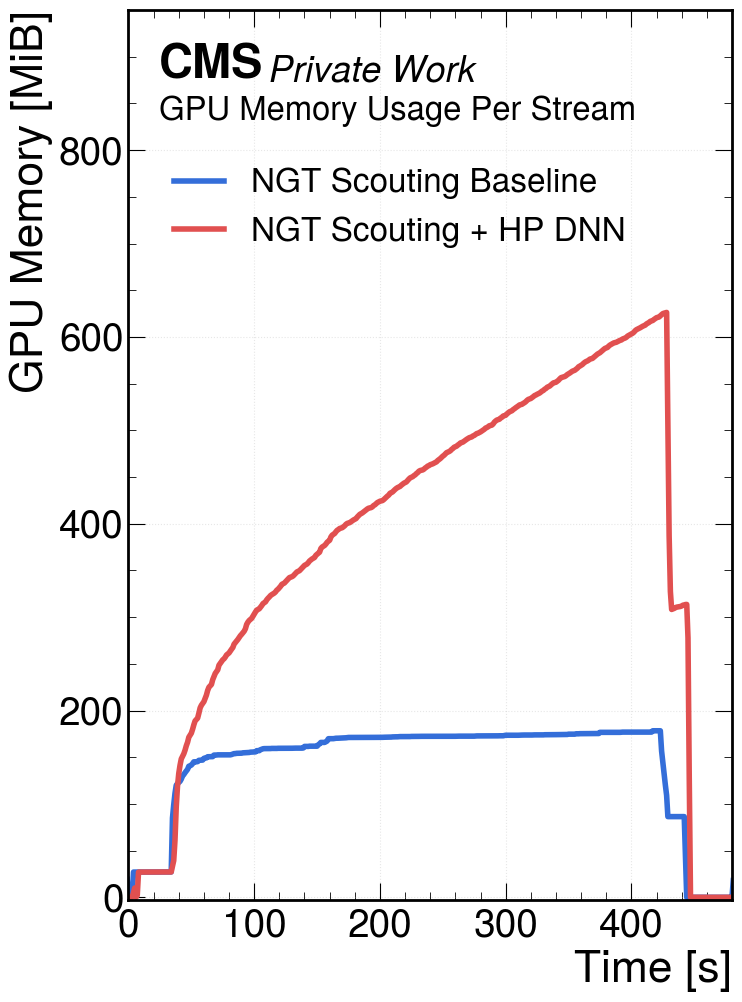

In [62]:
files = [
    "benchmark/gpu_memory_Patatrack_baseline_16j_16t_16s.csv",
    "benchmark/gpu_memory_Patatrack_TorchDNN_16j_16t_16s_original.csv",
    #"benchmark/gpu_memory_Patatrack_TorchDNN_16j_16t_16s_FixedQueue.csv",
    #"benchmark/gpu_memory_Patatrack_cuBlas.csv",
    #"benchmark/gpu_memory_Patatrack_FP16.csv",
    #"benchmark/gpu_memory_Patatrack_TorchDNN_16j_16t_16s_final.csv",
    #"benchmark/CMSSW_17_0_X_2026-04-19-0000/gpu_memory_Patatrack_Torch-base-DNN_16j_16t_16s.csv",
    #"benchmark/CMSSW_17_0_X_2026-04-19-0000/gpu_memory_Patatrack_TorchDNN_track-only_2bathces_updated_16j_16t_16s.csv",
]

labels = [
    "NGT Scouting Baseline",
    "NGT Scouting + HP DNN",
    #"FixedQueueEDProducer + reduced cuBLAS",
    #"After reduced cuBLAS workspace",
    #"Inference in 2 mini-batches",
    #"NGT Scouting menu + HP DNN final",
    #"New Patatrack after",
]
setStyle(customized=True)
set_presentation_style(figsize=(8, 10.6))
plot_gpu_memory_overlay(files, labels, colors=palette,title=None, streams=256, xlims=[(790, 1220), (240, 720)], ylims=(-3, 950), save_pdf='before_dev.pdf')#

   elapsed_seconds  memory_mib
0                0           0
1                1           0
2                2          29
3                3           0
4                4           0
elapsed_seconds    int64
memory_mib         int64
dtype: object
   elapsed_seconds  memory_mib
0                0           0
1                1           0
2                2          10
3                3           0
4                4           0
elapsed_seconds    int64
memory_mib         int64
dtype: object
   elapsed_seconds  memory_mib
0                0           0
1                1           0
2                2          42
3                3           0
4                4           0
elapsed_seconds    int64
memory_mib         int64
dtype: object
   elapsed_seconds  memory_mib
0                3           4
1                4          16
2                9           4
3               15           4
4               17         294
elapsed_seconds    int64
memory_mib         int64
dtype: object


TypeError: cannot unpack non-iterable NoneType object

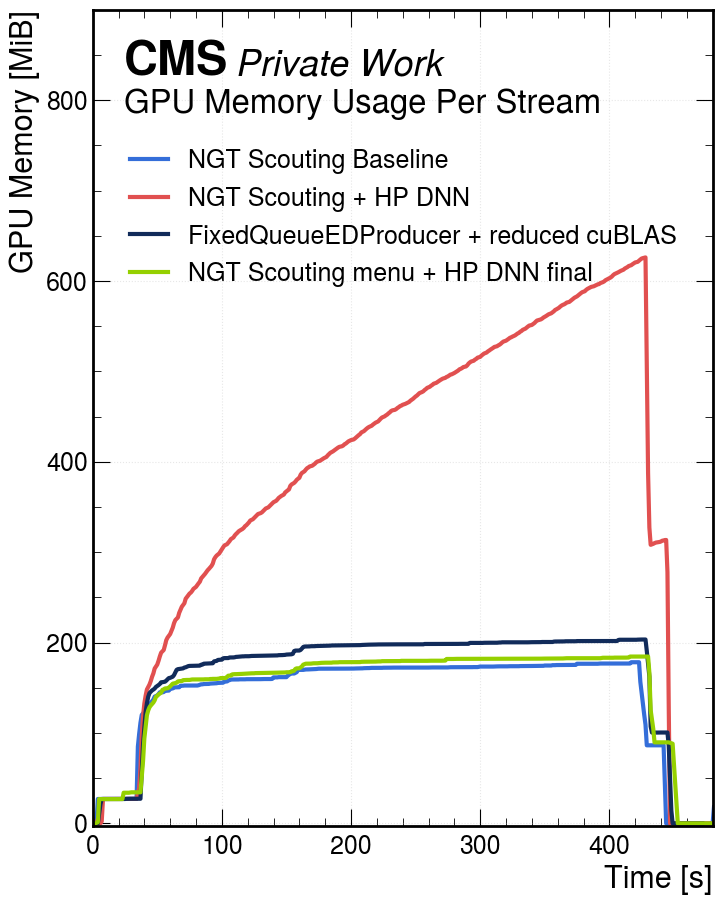

In [20]:
files = [
    "benchmark/gpu_memory_Patatrack_baseline_16j_16t_16s.csv",
    "benchmark/gpu_memory_Patatrack_TorchDNN_16j_16t_16s_original.csv",
    #"benchmark/gpu_memory_Patatrack_TorchDNN_16j_16t_16s_FixedQueue.csv",
    "benchmark/gpu_memory_Patatrack_cuBlas.csv",
    #"benchmark/gpu_memory_Patatrack_FP16.csv",
    "benchmark/gpu_memory_Patatrack_TorchDNN_16j_16t_16s_final.csv",
    #"benchmark/CMSSW_17_0_X_2026-04-19-0000/gpu_memory_Patatrack_Torch-base-DNN_16j_16t_16s.csv",
    #"benchmark/CMSSW_17_0_X_2026-04-19-0000/gpu_memory_Patatrack_TorchDNN_track-only_2bathces_updated_16j_16t_16s.csv",
]

labels = [
    "NGT Scouting Baseline",
    "NGT Scouting + HP DNN",
    "FixedQueueEDProducer + reduced cuBLAS",
    #"After reduced cuBLAS workspace",
    #"Inference in 2 mini-batches",
    "NGT Scouting menu + HP DNN final",
    #"New Patatrack after",
]
setStyle(customized=True)
set_presentation_style(figsize=(8, 10.6))
plot_gpu_memory_overlay(files, labels, colors=palette,title=None, streams=256, xlims=[(790, 1220), (240, 720), (250, 730), (790, 1220)], ylims=(-3, 900))#

   elapsed_seconds  memory_mib
0                0           0
1                1           0
2                2          29
3                3           0
4                4           0
elapsed_seconds    int64
memory_mib         int64
dtype: object
   elapsed_seconds  memory_mib
0                0           0
1                1           0
2                2          10
3                3           0
4                4           0
elapsed_seconds    int64
memory_mib         int64
dtype: object
   elapsed_seconds  memory_mib
0                0           0
1                1           0
2                2          42
3                3           0
4                4           0
elapsed_seconds    int64
memory_mib         int64
dtype: object
   elapsed_seconds  memory_mib
0                3           4
1                4          16
2                9           4
3               15           4
4               17         294
elapsed_seconds    int64
memory_mib         int64
dtype: object


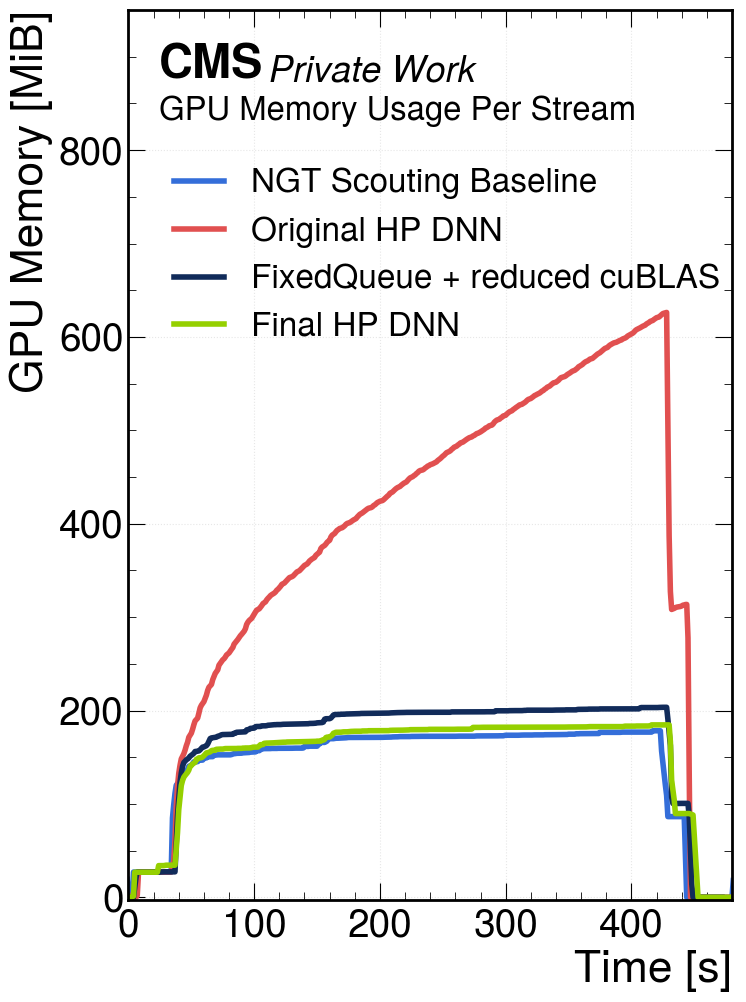

In [61]:
files = [
    "benchmark/gpu_memory_Patatrack_baseline_16j_16t_16s.csv",
    "benchmark/gpu_memory_Patatrack_TorchDNN_16j_16t_16s_original.csv",
    #"benchmark/gpu_memory_Patatrack_TorchDNN_16j_16t_16s_FixedQueue.csv",
    "benchmark/gpu_memory_Patatrack_cuBlas.csv",
    #"benchmark/gpu_memory_Patatrack_FP16.csv",
    "benchmark/gpu_memory_Patatrack_TorchDNN_16j_16t_16s_final.csv",
    #"benchmark/CMSSW_17_0_X_2026-04-19-0000/gpu_memory_Patatrack_Torch-base-DNN_16j_16t_16s.csv",
    #"benchmark/CMSSW_17_0_X_2026-04-19-0000/gpu_memory_Patatrack_TorchDNN_track-only_2bathces_updated_16j_16t_16s.csv",
]

labels = [
    "NGT Scouting Baseline",
    "Original HP DNN",
    "FixedQueue + reduced cuBLAS",
    #"After reduced cuBLAS workspace",
    #"Inference in 2 mini-batches",
    "Final HP DNN",
    #"New Patatrack after",
]
setStyle(customized=False)
set_presentation_style(figsize=(8, 10.6))
plot_gpu_memory_overlay(files, labels, colors=palette,title=None, streams=256, xlims=[(790, 1220), (240, 720), (250, 730), (790, 1220)], ylims=(-3, 950), save_pdf='final.pdf')#

   elapsed_seconds  memory_mib
0                0           0
1                2           0
2                3           0
3                4           0
4                5           0
elapsed_seconds    int64
memory_mib         int64
dtype: object
   elapsed_seconds  memory_mib
0                0           0
1                1           0
2                2           0
3                3           0
4                4           0
elapsed_seconds    int64
memory_mib         int64
dtype: object


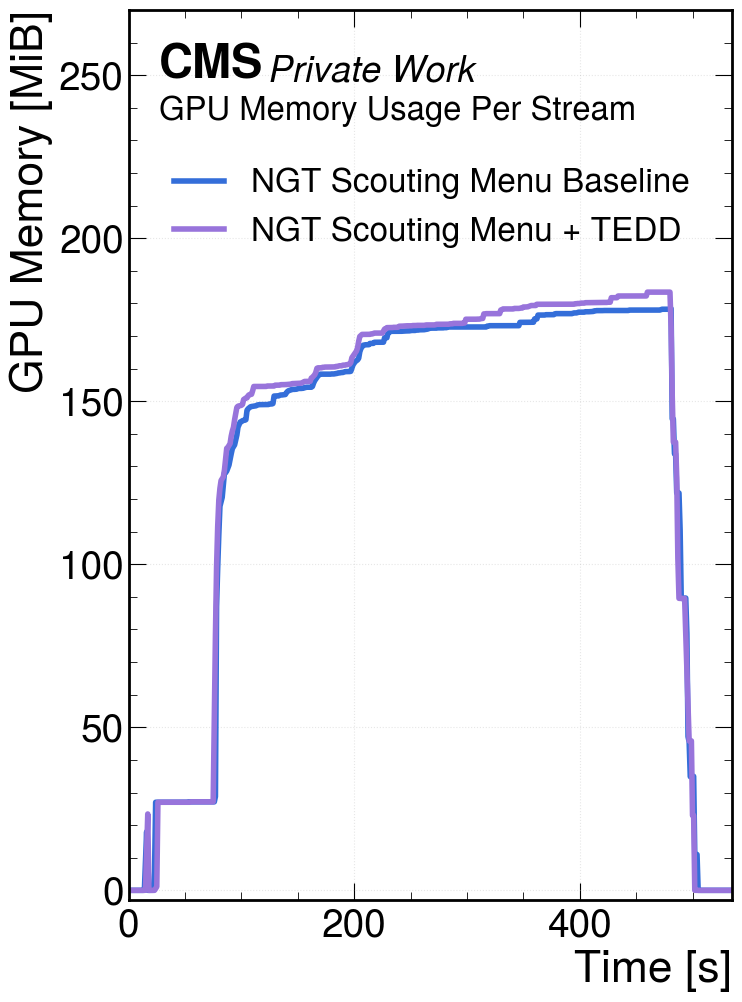

In [52]:
files = [
    "benchmark/17_0_0_pre1_baseline.csv",
    "benchmark/17_0_0_pre1_TID.csv",
]

labels = [
    "NGT Scouting Menu Baseline",
    "NGT Scouting Menu + TEDD",
]

setStyle(customized=True)
set_presentation_style(figsize=(8, 10.6))
plot_gpu_memory_overlay(files, labels, colors=['#346ED9', '#9874DB'],title=None, streams=256, xlims=[(1295, 1830), (1305, 1830)], ylims=(-3, 270), save_pdf='TEDD-gpu.pdf')#

   elapsed_seconds  memory_mib
0                0           0
1                2           0
2                3           0
3                4           0
4                5           0
elapsed_seconds    int64
memory_mib         int64
dtype: object
   elapsed_seconds  memory_mib
0                0           0
1                1           0
2                2           0
3                3           0
4                4           0
elapsed_seconds    int64
memory_mib         int64
dtype: object


TypeError: cannot unpack non-iterable NoneType object

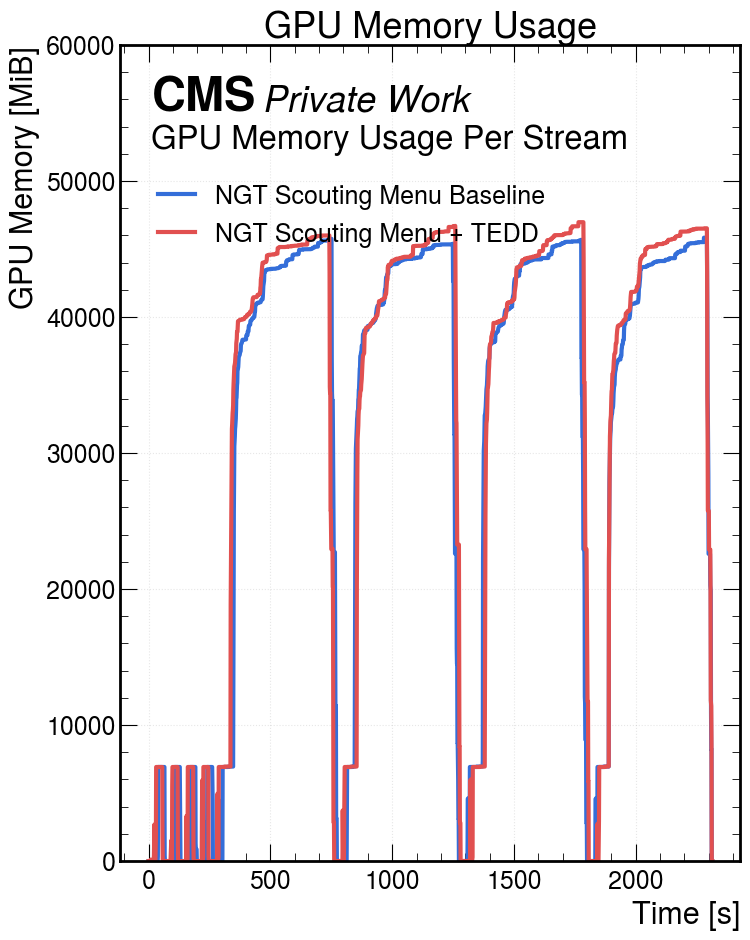

In [31]:
files = [
    "benchmark/17_0_0_pre1_baseline.csv",
    "benchmark/17_0_0_pre1_TID.csv",
]

labels = [
    "NGT Scouting Menu Baseline",
    "NGT Scouting Menu + TEDD",
]

plot_gpu_memory_overlay(files, labels, colors=palette, ylims=(-3, 6e4))

   elapsed_seconds  memory_mib
0                0           0
1                1           0
2                2          29
3                3           0
4                4           0
elapsed_seconds    int64
memory_mib         int64
dtype: object
   elapsed_seconds  memory_mib
0                3           4
1                4          16
2                9           4
3               15           4
4               17         294
elapsed_seconds    int64
memory_mib         int64
dtype: object


AttributeError: 'NoneType' object has no attribute 'set_fontsize'

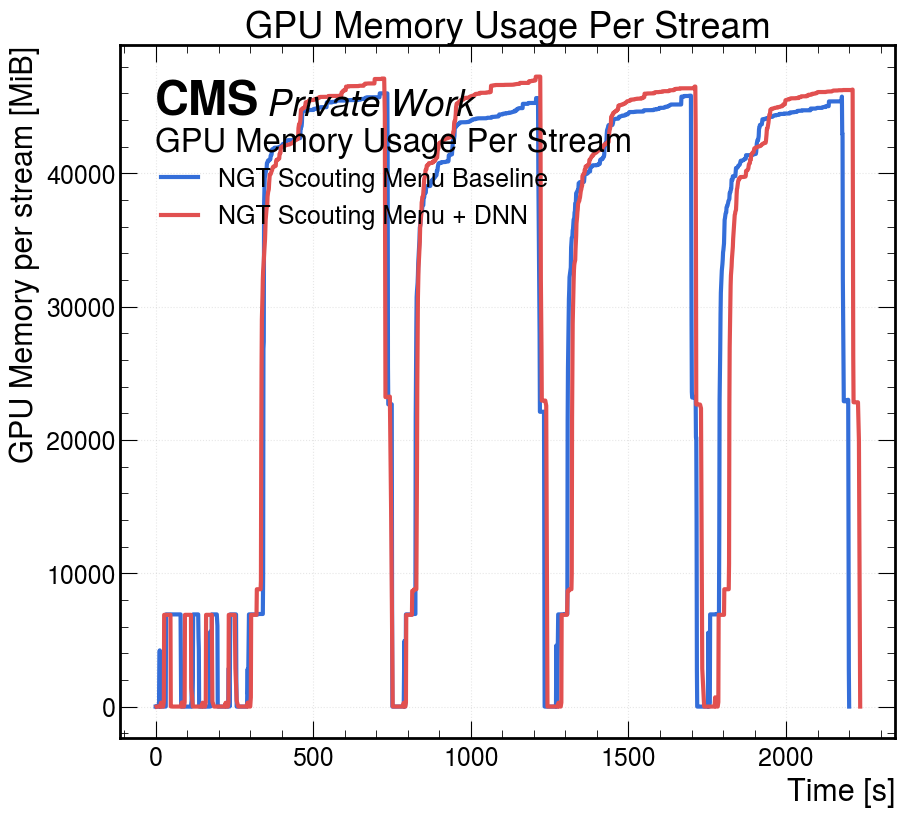

In [37]:
files = [
    "benchmark/gpu_memory_Patatrack_baseline_16j_16t_16s.csv",
    "benchmark/gpu_memory_Patatrack_TorchDNN_16j_16t_16s_final.csv",
]

labels = [
    "NGT Scouting Menu Baseline",
    "NGT Scouting Menu + DNN"
]
set_presentation_style(figsize=(10,9))
plot_gpu_memory_overlay(files, labels, title="GPU Memory Usage Per Stream", ylabel="GPU Memory per stream [MiB]", streams = 1, colors=palette)

In [ ]:
files = [
    "benchmark/tests_on_baseline/gpu_memory_Patatrack_16_0_0_pre3_16j_16t_16s.csv",
    "benchmark/tests_on_default/gpu_memory_PatatrackTOB_TorchDNNfalseSegments.csv",
    "benchmark/tests_on_default/gpu_memory_PatatrackTOB_TorchDNNtrueSegments.csv"
]

labels = [
    "Baseline",
    "Torch",
    "Torch DNN + expandable segments"
]

plot_gpu_memory_overlay(files, labels)

In [ ]:
files = [
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_baseline.csv",
    "benchmark/tests_on_default/gpu_memory_PatatrackTOB_TorchDNNfalseSegments.csv",
    "benchmark/tests_on_default/gpu_memory_PatatrackTOB_TorchDNNtrueSegments.csv",
    "benchmark/tests_on_torchQueue/gpu_memory_Patatrack_TorchDNN_cuBlas_16j_16t_16s.csv"
]

labels = [
    "Baseline",
    "Torch",
    "Torch + expandable segments",
    "Torch Stream decoupling"
]

plot_gpu_memory_overlay(files, labels)

In [ ]:
files = [
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_baseline.csv",
    "benchmark/tests_on_torchQueue/gpu_memory_Patatrack_TorchDNN_cuBlas_16j_16t_16s.csv"
]

labels = [
    "Baseline",
    "Torch Stream decoupling"
]

plot_gpu_memory_overlay(files, labels)

In [ ]:
files = [
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_baseline.csv",
    "benchmark/tests_on_torchQueue/gpu_memory_Patatrack_TorchDNN_cuBlas_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_bis_16j_16t_16s.csv"
    
]

labels = [
    "Baseline",
    "Torch Stream decoupling",
    "Torch Stream decoupling no cuBLAS"
]

plot_gpu_memory_overlay(files, labels)

In [ ]:
files = [
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_baseline.csv",
    "benchmark/tests_on_torchQueue/gpu_memory_Patatrack_TorchDNN_cuBlas_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_bis_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_16j_16t_16s.csv",    
]

labels = [
    "Baseline",
    "Torch Stream decoupling",
    "Torch Stream decoupling no cuBLAS",
    "Torch Stream decoupling no cuBLAS FP16",
]

plot_gpu_memory_overlay(
    files,
    labels,
    skip_labels={"Torch Stream decoupling"}
)

In [ ]:
files = [
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_baseline.csv",
    "benchmark/tests_on_torchQueue/gpu_memory_Patatrack_TorchDNN_cuBlas_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_bis_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_2batches_bis_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_4batches_16j_16t_16s.csv"
    
]

labels = [
    "Baseline",
    "Torch Stream decoupling",
    "Torch Stream decoupling no cuBLAS",
    "Torch Stream decoupling no cuBLAS FP16",
    "Torch Stream decoupling no cuBLAS FP16 2 batches",
    "Torch Stream decoupling no cuBLAS FP16 4 batches",
]

plot_gpu_memory_overlay(
    files,
    labels,
    skip_labels={"Torch Stream decoupling"}
)

In [ ]:
files = [
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_baseline.csv",
    "benchmark/tests_on_torchQueue/gpu_memory_Patatrack_TorchDNN_cuBlas_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_bis_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_2batches_bis_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_4batches_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_minimalBlas_FP16_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_minimalBlas_FP16_2batches_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_minimalBlas_FP16_4batches_16j_16t_16s.csv"
    
]

labels = [
    "Baseline",
    "Torch Stream decoupling",
    "Torch Stream decoupling no cuBLAS",
    "Torch Stream decoupling no cuBLAS FP16",
    "Torch Stream decoupling no cuBLAS FP16 2 batches",
    "Torch Stream decoupling no cuBLAS FP16 4 batches",
    "Torch Stream decoupling min cuBLAS FP16",
    "Torch Stream decoupling min cuBLAS FP16 2 batches",
    "Torch Stream decoupling min cuBLAS FP16 4 batches",
]

plot_gpu_memory_overlay(
    files,
    labels,
    skip_labels={"Torch Stream decoupling"}
)

In [ ]:
files = [
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_baseline.csv",
    "benchmark/tests_on_torchQueue/gpu_memory_Patatrack_TorchDNN_cuBlas_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_bis_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_2batches_bis_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_4batches_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_minimalBlas_FP16_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_minimalBlas_FP16_2batches_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_minimalBlas_FP16_4batches_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_minimalBlas_FP16_Markus_16j_16t_16s.csv",
]

labels = [
    "Baseline",
    "Torch Stream decoupling",
    "Torch Stream decoupling no cuBLAS",
    "Torch Stream decoupling no cuBLAS FP16",
    "Torch Stream decoupling no cuBLAS FP16 2 batches",
    "Torch Stream decoupling no cuBLAS FP16 4 batches",
    "Torch Stream decoupling min cuBLAS FP16",
    "Torch Stream decoupling min cuBLAS FP16 2 batches",
    "Torch Stream decoupling min cuBLAS FP16 4 batches",
    "Torch Stream decoupling min cuBLAS FP16 Markus",
]

plot_gpu_memory_overlay(
    files,
    labels
    #skip_labels={"Torch Stream decoupling"}
)

In [ ]:
files = [
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_baseline.csv",
    "benchmark/tests_on_torchQueue/gpu_memory_Patatrack_TorchDNN_cuBlas_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_bis_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_2batches_bis_16j_16t_16s.csv",
    "benchmark/tests_on_torchQueueCUBLAS/CMSSW_16_1_0_pre2/gpu_memory_Patatrack_TorchDNN_noBlas_FP16_4batches_16j_16t_16s.csv"
    
]

labels = [
    "Baseline",
    "Torch Stream decoupling",
    "Torch Stream decoupling no cuBLAS",
    "Torch Stream decoupling no cuBLAS FP16",
    "Torch Stream decoupling no cuBLAS FP16 2 batches",
    "Torch Stream decoupling no cuBLAS FP16 4 batches",
]

plot_gpu_memory_overlay(
    files,
    labels,
    skip_labels={"Torch Stream decoupling", "Torch Stream decoupling no cuBLAS", "Torch Stream decoupling no cuBLAS FP16"}
)

In [ ]:
files = [
    "benchmark/tests_on_torchQueue/gpu_memory_vs_time_1stream.csv",
    "benchmark/tests_on_torchQueue/gpu_memory_vs_time_2stream.csv",
    "benchmark/tests_on_torchQueue/gpu_memory_vs_time_3stream.csv",
    "benchmark/tests_on_torchQueue/gpu_memory_vs_time_4stream.csv",
    "benchmark/tests_on_torchQueue/no_model/gpu_memory_vs_time_1stream.csv",
    "benchmark/tests_on_torchQueue/no_model/gpu_memory_vs_time_2stream.csv",
    "benchmark/tests_on_torchQueue/no_model/gpu_memory_vs_time_3stream.csv",
    "benchmark/tests_on_torchQueue/no_model/gpu_memory_vs_time_4stream.csv"
]

labels = [
    "TorchQueue 1 stream",
    "TorchQueue 2 stream",
    "TorchQueue 3 stream",
    "TorchQueue 4 stream",
    "No model 1 stream",
    "No model 2 stream",
    "No model 3 stream",
    "No model 4 stream"
]

plot_gpu_memory_overlay(files, labels)

## Timing

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def compare_bar_with_diff(x_label, values, labels, colors):
    """
    Create a bar plot comparing multiple values at the same x position,
    and a subplot showing differences relative to the first value.

    Parameters:
    - x_label (str): Label for the x-axis
    - values (list of float): Values to compare
    - labels (list of str): Labels for legend
    - colors (list of str): Colors for each bar
    """

    # Basic validation
    if not (len(values) == len(labels) == len(colors)):
        raise ValueError("values, labels, and colors must have the same length")

    n = len(values)
    x = np.arange(n)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=False)

    # --- Top plot: bar comparison ---
    bar_positions = np.arange(n)
    ax1.bar(bar_positions, values, color=colors)

    ax1.set_xticks(bar_positions)
    ax1.set_xticklabels(labels)
    ax1.set_ylabel("Time [ms]")
    ax1.set_title(f"{x_label}")

    # --- Bottom plot: differences ---
    baseline = values[0]
    diffs = [v - baseline for v in values]

    ax2.bar(bar_positions, diffs, color=colors)
    ax2.axhline(0)  # reference line

    ax2.set_xticks(bar_positions)
    ax2.set_xticklabels(labels)
    ax2.set_ylabel("Difference [ms]")
    #ax2.set_title(f"Difference from '{labels[0]}'")
    plt.tight_layout()
    plt.show()

In [ ]:
values = [5.87, 6.17]
labels = ["cuBLAS workspace", "no cuBLAS workspace"]
colors = ["orange", "green"]

compare_bar_with_diff("Timing of hltPhase2PixelTrackTorchSelector", values, labels, colors)

In [ ]:
values = [6.45, 10.83, 18.08]
labels = ["1 batch", "2 batches", "4 batches"]
colors = ["tab:red", "tab:purple", "tab:brown"]

compare_bar_with_diff("Timing of hltPhase2PixelTrackTorchSelector", values, labels, colors)